In [1]:
import pickle as pk
import dill as dill
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os


In [2]:
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_probe_all_deproj_cib_1p7_dBeta_2500_6000_num_chains_80.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_probe_all_deproj_cib_1p7_dBeta_2000_4000_num_chains_32.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_2000_warmup_4000_num_chains_32_gtysc_True_Y3xipmsc_False.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_probe_gty_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_2500_warmup_6000_num_chains_80_gtysc_True_Y3xipmsc_True.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_probe_xip_xim_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_2500_warmup_6000_num_chains_80_gtysc_True_Y3xipmsc_True.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_2500_warmup_6000_num_chains_80_gtysc_True_Y3xipmsc_False.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_2500_warmup_6000_num_chains_80_gtysc_True_Y3xipmsc_False.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_probe_all_deproj_cib_1p7_dBeta_2000_4000_num_chains_32.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v2_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_3000_warmup_5000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v8_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4000_warmup_3000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v9_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4500_warmup_3500_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v9_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4000_warmup_3000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v9_probe_xip_xim_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4000_warmup_3000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v9_probe_gty_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4000_warmup_3000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v10fixbaryon_probe_xip_xim_modelmatter_halofit_deproj_cib_1p7_dBeta_samples_8000_warmup_7000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_True.pkl','rb'))
df.keys()



dict_keys(['A_IA', 'A_IA_base', 'Delta_z_bias_array', 'Delta_z_bias_array_decentered', 'Ob0', 'Ob0_base', 'Om0', 'Om0_base', 'diverging', 'eta_IA', 'eta_IA_base', 'h', 'h_base', 'mult_shear_bias_array', 'mult_shear_bias_array_decentered', 'ns', 'ns_base', 'potential_energy', 'sigma8', 'sigma8_base', 'RUN_SETTINGS'])

In [3]:
# df['RUN_SETTINGS']



In [4]:
sig8 = df['sigma8']
# nchains = 80
nchains = 64
sig8_rs = sig8.reshape(nchains,-1)
# print(sig8_rs.shape)
from numpyro.diagnostics import autocorrelation, autocovariance

acorr = autocorrelation(sig8_rs, axis=1)
ind_del = []
for ji in range(acorr.shape[0]):
    if np.std(acorr[ji,100:]) > 0.075:
        ind_del.append(ji)
# autocovariance(sig8_rs).shape


In [5]:
print(len(ind_del), ind_del)


28 [5, 7, 9, 11, 17, 18, 24, 27, 31, 36, 37, 38, 39, 40, 41, 43, 44, 46, 47, 49, 51, 55, 56, 57, 58, 59, 60, 61]


(288000,)
(288000,)
(288000,)
(288000,)
(288000,)
(288000,)
(288000,)
(288000,)
(145800, 22) (36, 4050, 22)
Removed no burn in
1.0137504783680407 1635.3430543148254


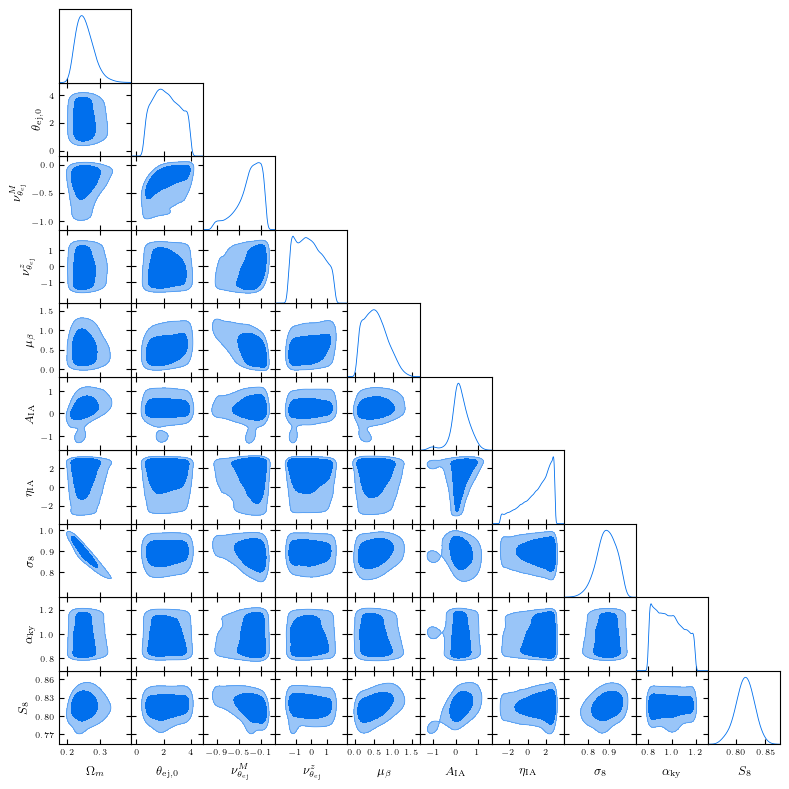

In [6]:
samps = []
keys = []
for key in df:
    if ('base' not in key) and ('decentered' not in key):
        if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
        # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
            if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                for jb in range(4):
                    samps.append(df[key][:, jb])
                    keys.append(key + '_' + str(jb))
                    print(df[key][:, jb].shape)
            # print(samps[0].shape)
            # print(df[key].shape)
            else:
                samps.append(df[key])
                keys.append(key)

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
# ind_thetaejM = keys.index('nu_theta_ej_M')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')

import getdist
from getdist import plots, MCSamples

names = keys


save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
labels_all = {'A_IA':r'$A_{\rm IA}$',
 'Ob0':r'$\Omega_b$',
 'Om0':r'$\Omega_m$',
 'eta_IA':r'$\eta_{\rm IA}$',
 'log10_Mc0':r'$\log(M_c)$',
 'theta_co_0':r'$\theta_{\rm co, 0}$',
 'gamma_rhogas':r'$\gamma$',
 'nu_z':r'$\nu_z$',
 'h':r'$h$',
 'ns':r'$n_s$',
 'mu_beta':r'$\mu_{\beta}$',
 'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
 'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
 'nu_theta_co_z':r'$\nu^{z}_{\theta_{\rm co}}$', 
 'log10_Mc0':r'$\log(M_c)$',
    'delta_rhogas':r'$\delta$',
    'gamma_rhogas':r'$\gamma$',
 'sigma8':r'$\sigma_8$',
 'theta_ej_0':r'$\theta_{\rm ej, 0}$',
 'S8':r'$S_8$',
 'alpha_nt':r'$\alpha_{\rm nt}$',
 'alpha_ky':r'$\alpha_{\rm ky}$',
 'alpha_kk':r'$\alpha_{\rm kk}$'
}

labels = []

for key in keys:
    if key in labels_all.keys():
        labels.append(labels_all[key])
    else:
        labels.append(r'm')

ind_frac_rm = 0.1
# nchains = 80
samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
nsamp_per_chain = samps_sel.shape[1]
nrm = int(ind_frac_rm * nsamp_per_chain)
samps_sel = samps_sel[:, nrm:, :]

# # ind_del = np.array([4, 10])
# # ind_del = np.array([3])
# # ind_del = np.array([1,2,4,7])
# # ind_del = np.array([0,7,8,9,10])
# ind_del = [0]
# # ind_del = [3,5,8]
# # ind_del = [0,3,4,5,6,7,8,9,10,11]
if len(ind_del) > 0:
    samps_sel = np.delete(samps_sel, ind_del, axis=0)
else:
    samps_sel = samps_sel

samps = samps_sel.reshape(-1, samps_sel.shape[-1])
print(samps.shape, samps_sel.shape)

# saved = {'samps':samps, 'keys':keys, 'labels':labels, 'names':names}
# savedir = '/projects/bdne/spandey3/GODMAX/results/ACTxDES/'
# pk.dump(saved, open(savedir + 'samps_probes_all_npfNov_response_response.pkl', 'wb'))

# samps = samps[60000:80000,:]
samples = MCSamples(samples=samps,names = names, labels = labels)

from numpyro.diagnostics import gelman_rubin, effective_sample_size
ind_gr = ind_sigma8
gr = gelman_rubin(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
ess = effective_sample_size(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
print(gr, ess)

# pl.figure()
# for ji in range(samps_sel.shape[0]):
    # print(ji, np.std(samps_sel[ji, :, ind_thetaejM]), np.mean(samps_sel[ji, :, ind_thetaejM]))
    # pl.plot(samps_sel[ji, :, ind_thetaejM], alpha=0.1)
# pl.savefig(save_plot_dir + 'temp.pdf')
# pl.show()
# params = ['Om0', 'nu_theta_ej_M',  'theta_ej_0', 'nu_theta_ej_z', 'theta_co_0', 'S8']
# params = ['Om0', 'nu_theta_ej_M',  'theta_ej_0', 'nu_theta_ej_z', 'theta_co_0', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M',  'nu_theta_ej_z', 'sigma8']
# params = ['nu_theta_ej_M','nu_theta_ej_z','theta_ej_0','theta_co_0','gamma_rhogas', 'mu_beta', 'delta_rhogas','log10_Mc0', 'alpha_ky']
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M','nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'alpha_ky', 'alpha_kk', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M','nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'alpha_ky', 'alpha_kk', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'gamma_rhogas', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8','alpha_1h2h_ym']
# params = ['Om0', 'theta_ej_0', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M', 'nu_theta_ej_z','A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M',  'nu_theta_ej_z',  'mu_beta','A_IA', 'eta_IA', 'sigma8', 'alpha_ky', 'S8', 'delta_rhogas']
# params = ['Om0', 'theta_ej_0',  'nu_theta_ej_z',  'mu_beta','A_IA', 'eta_IA', 'sigma8', 'alpha_ky', 'S8', 'delta_rhogas']
params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M',  'nu_theta_ej_z',  'mu_beta','A_IA', 'eta_IA', 'sigma8', 'alpha_ky', 'S8']
# params = ['Om0', 'theta_ej_0',  'nu_theta_ej_z', 'A_IA', 'eta_IA', 'sigma8', 'alpha_ky', 'S8']
# params = ['Om0', 'nu_theta_ej_M', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'theta_co_0', 'sigma8', 'gamma_rhogas', 'S8']

g = plots.get_subplot_plotter(width_inch=8)
# g.triangle_plot([samples_xipxim, samples_gty, samples_all], params, filled=True)
g.triangle_plot([samples], params, filled=True)
# g.triangle_plot([samples], filled=True)

# g.export(save_plot_dir + 'xipm_simple_wide.pdf')
# save_plot_dir = '/projects/bdne/spandey3/GODMAX/results/plots/ACTxDES/'
# g.export(save_plot_dir + 'test_fix_thetaej_mubeta.pdf')
# g.export(save_plot_dir + 'all_params.pdf')
# 
import matplotlib
%matplotlib inline
pl.show()



In [26]:
samps_sel.shape


(33, 3600, 22)

In [7]:
from getdist import MCSamples
def get_param_names(filename):
    with open(filename,"r") as fi:
        param_names = np.array((fi.readline()[1:].split()))
    return param_names

def replace_fancy(names, fancy_dic):
    output_names = []
    ind_data = []
    for ii in range(len(names)):
        if (names[ii] in fancy_dic):
            output_names.append(fancy_dic[names[ii]])
            ind_data.append(ii)
    return np.array(output_names), np.array(ind_data)
# fancy_dictionary = {'cosmological_parameters--omega_m':r'$\Omega_m$','cosmological_parameters--s8':r'$S_8$'} 
filename = '/projects/bdne/spandey3/GODMAX/results/ACTxDES/chain_1x2pt_lcdm_SR_maglim.txt'
data = np.loadtxt(filename)
weights = np.loadtxt(filename)[:,-1]
param_names = get_param_names(filename)
# 
fancy_dictionary = {'cosmological_parameters--omega_m':r'$\Omega_m$','COSMOLOGICAL_PARAMETERS--SIGMA_8':r'$\sigma_8$'} 
param_names_fancy, selection = replace_fancy(np.array(param_names), fancy_dictionary)

data_y3kp = data[:,selection]
param_names = param_names[selection]
param_names_fancy = param_names_fancy

data_Om = data_y3kp[:,0]
data_sigma8 = data_y3kp[:,1]
data_S8 = data_sigma8 * np.sqrt(data_Om/0.3)
data = np.column_stack((data_Om, data_sigma8, data_S8))

# all_data.append(data)

# samples_y3kp = MCSamples(samples=data_y3kp,\
#                     weights=weights, \
#                     names = ['Om0','sigma8'], labels = [r'$\Omega_m$', r'$\sigma_8$'])

samples_y3kp = MCSamples(samples=data,\
                    weights=weights, \
                    names = ['Om0','sigma8','S8'], labels = [r'$\Omega_m$', r'$\sigma_8$', r'$S_8$'])



Removed no burn in


In [8]:
from getdist import MCSamples
def get_param_names(filename):
    with open(filename,"r") as fi:
        param_names = np.array((fi.readline()[1:].split()))
    return param_names

def replace_fancy(names, fancy_dic):
    output_names = []
    ind_data = []
    for ii in range(len(names)):
        if (names[ii] in fancy_dic):
            output_names.append(fancy_dic[names[ii]])
            ind_data.append(ii)
    return np.array(output_names), np.array(ind_data)
# fancy_dictionary = {'cosmological_parameters--omega_m':r'$\Omega_m$','cosmological_parameters--s8':r'$S_8$'} 
filename = '/projects/bdne/spandey3/GODMAX/data/DESxACT/chain_p-TTTEEE-lowE_lcdm.txt'
data = np.loadtxt(filename)
weights = np.loadtxt(filename)[:,-1]
param_names = get_param_names(filename)
# 
fancy_dictionary = {'cosmological_parameters--omega_m':r'$\Omega_m$','COSMOLOGICAL_PARAMETERS--SIGMA_8':r'$\sigma_8$'} 
param_names_fancy, selection = replace_fancy(np.array(param_names), fancy_dictionary)

data_y3kp = data[:,selection]
param_names = param_names[selection]
param_names_fancy = param_names_fancy

data_Om = data_y3kp[:,0]
data_sigma8 = data_y3kp[:,1]
data_S8 = data_sigma8 * np.sqrt(data_Om/0.3)
data = np.column_stack((data_Om, data_sigma8, data_S8))

# all_data.append(data)

# samples_y3kp = MCSamples(samples=data_y3kp,\
#                     weights=weights, \
#                     names = ['Om0','sigma8'], labels = [r'$\Omega_m$', r'$\sigma_8$'])

samples_planck = MCSamples(samples=data,\
                    weights=weights, \
                    names = ['Om0','sigma8','S8'], labels = [r'$\Omega_m$', r'$\sigma_8$', r'$S_8$'])



Removed no burn in


In [9]:
from getdist import MCSamples
def get_param_names(filename):
    with open(filename,"r") as fi:
        param_names = np.array((fi.readline()[1:].split()))
    return param_names

def replace_fancy(names, fancy_dic):
    output_names = []
    ind_data = []
    for ii in range(len(names)):
        if (names[ii] in fancy_dic):
            output_names.append(fancy_dic[names[ii]])
            ind_data.append(ii)
    return np.array(output_names), np.array(ind_data)
# fancy_dictionary = {'cosmological_parameters--omega_m':r'$\Omega_m$','cosmological_parameters--s8':r'$S_8$'} 
filename1 = '/projects/bdne/spandey3/cs_godmax/cosmosis-standard-library/output/des-y3_shearonly_NLA_godmax_emcee.txt'
data1 = np.loadtxt(filename1)
weights1 = np.ones(data1.shape[0])

filename2 = '/projects/bdne/spandey3/cs_godmax/cosmosis-standard-library/output/des-y3_shearonly_NLA_godmax_emcee_2.txt'
data2 = np.loadtxt(filename2)
weights2 = np.ones(data2.shape[0])

filename3 = '/projects/bdne/spandey3/cs_godmax/cosmosis-standard-library/output/des-y3_shearonly_NLA_godmax_emcee_3.txt'
data3 = np.loadtxt(filename3)
weights3 = np.ones(data3.shape[0])

filename4 = '/projects/bdne/spandey3/cs_godmax/cosmosis-standard-library/output/des-y3_shearonly_NLA_godmax_emcee_4.txt'
data4 = np.loadtxt(filename4)
weights4 = np.ones(data4.shape[0])

data = np.concatenate((data1, data2, data3, data4), axis=0)
weights = np.concatenate((weights1, weights2, weights3, weights4))

print(data1.shape, data2.shape, data3.shape, data4.shape)

param_names = get_param_names(filename1)
# 
print(param_names)

fancy_dictionary = {'cosmological_parameters--omega_m':r'$\Omega_m$','COSMOLOGICAL_PARAMETERS--SIGMA_8':r'$\sigma_8$', 'shear_calibration_parameters--m4':r'$m_4$', 'wl_photoz_errors--bias_4':r'$\Delta z_4$'} 
param_names_fancy, selection = replace_fancy(np.array(param_names), fancy_dictionary)

data_y3kp = data[:,selection]
param_names = param_names[selection]
param_names_fancy = param_names_fancy

ind_Om = np.where(param_names == 'cosmological_parameters--omega_m')[0][0]
ind_sigma8 = np.where(param_names == 'COSMOLOGICAL_PARAMETERS--SIGMA_8')[0][0]
data_Om = data_y3kp[:,ind_Om]
data_sigma8 = data_y3kp[:,ind_sigma8]
data_S8 = data_sigma8 * np.sqrt(data_Om/0.3)
data = np.concatenate((data_y3kp, data_S8[:,None]), axis=-1)

# all_data.append(data)
indfac_burnin = 0.01
indstart = int(indfac_burnin*data.shape[0])

# samples_y3kp = MCSamples(samples=data_y3kp,\
#                     weights=weights, \
#                     names = ['Om0','sigma8'], labels = [r'$\Omega_m$', r'$\sigma_8$'])

samples_y3kp_nla = MCSamples(samples=data[indstart:,:],\
                    weights=weights[indstart:], \
                    names = ['Om0','mult_shear_bias_array_3', 'Delta_z_bias_array_3','sigma8', 'S8'], labels = [r'$\Omega_m$',r'$m_1$', r'$\Delta z_1$', r'$\sigma_8$', r'$S_8$'])




(185760, 20) (286080, 20) (560640, 20) (541440, 20)
['cosmological_parameters--omega_m' 'cosmological_parameters--h0'
 'cosmological_parameters--omega_b' 'cosmological_parameters--n_s'
 'cosmological_parameters--sigma_8' 'shear_calibration_parameters--m1'
 'shear_calibration_parameters--m2' 'shear_calibration_parameters--m3'
 'shear_calibration_parameters--m4' 'wl_photoz_errors--bias_1'
 'wl_photoz_errors--bias_2' 'wl_photoz_errors--bias_3'
 'wl_photoz_errors--bias_4' 'intrinsic_alignment_parameters--a1'
 'intrinsic_alignment_parameters--alpha1'
 'COSMOLOGICAL_PARAMETERS--SIGMA_8' 'COSMOLOGICAL_PARAMETERS--SIGMA_12'
 'DATA_VECTOR--2PT_CHI2' 'prior' 'post']
Removed no burn in


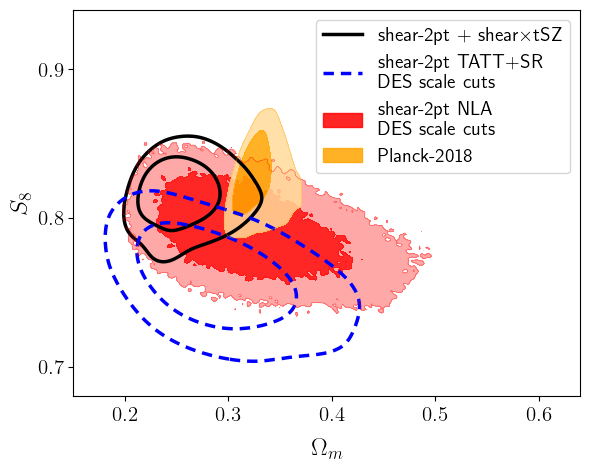

In [10]:
g = plots.getSinglePlotter(width_inch=6, ratio=0.8)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':2.5,'color':'black'},{'lw':2.5,'color':'blue'},{'lw':0.1,'color':'red'},{'lw':0.1,'color':'orange'},{'lw':0.1,'color':'green'}]

contour_args = {'filled': True, 'alpha': 0.7}
# g.plot_2d([samples_all, samples_gty, samples_xipm, samples_y3kp], 'Om0', 'sigma8', line_args=line_args, 
#             contour_lws=[1.5], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
#             ls=['-','--','','',''] ,
#             lims=[0.13, 0.5, 0.58, 1.0])  

# g.plot_2d([samples, samples_y3kp], 'Om0', 'sigma8', line_args=line_args, 
#             contour_lws=[1.5], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
#             ls=['-','--','','',''] ,
            # lims=[0.13, 0.5, 0.58, 1.0])  

# g.plot_2d([samples, samples_y3kp, samples_y3kp_nla, samples_planck], 'Om0', 'sigma8', line_args=line_args, 
#             contour_lws=[1.5], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
#             ls=['-','--','','',''] ,
#             lims=[0.18, 0.52, 0.58, 1.1])  

g.plot_2d([samples, samples_y3kp, samples_y3kp_nla, samples_planck], 'Om0', 'S8', line_args=line_args, 
            contour_lws=[1.5], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','--','','',''] ,
            lims=[0.15, 0.64, 0.68, 0.94])  

# g.add_legend([r'shear + shear$\times$tSZ',r'shear$\times$tSZ-only', r'shear-only',  r'Y3KP, shear-only'], legend_loc='upper right', fontsize=14)
g.add_legend([r'shear-2pt + shear$\times$tSZ',r'shear-2pt TATT+SR' + '\n' + 'DES scale cuts',r'shear-2pt NLA' + '\n' + 'DES scale cuts',  r'Planck-2018'], legend_loc='upper right', fontsize=14)
# g.export(save_plot_dir  + 'contour_Om0_S8_wPlanck.pdf')
import matplotlib
%matplotlib inline
pl.show()



In [42]:
df.keys()



dict_keys(['A_IA', 'A_IA_base', 'Delta_z_bias_array', 'Delta_z_bias_array_decentered', 'Ob0', 'Ob0_base', 'Om0', 'Om0_base', 'alpha_ky', 'alpha_ky_base', 'alpha_nt', 'alpha_nt_base', 'diverging', 'eta_IA', 'eta_IA_base', 'h', 'h_base', 'mu_beta', 'mu_beta_base', 'mult_shear_bias_array', 'mult_shear_bias_array_decentered', 'ns', 'ns_base', 'nu_theta_ej_z', 'nu_theta_ej_z_base', 'potential_energy', 'sigma8', 'sigma8_base', 'theta_ej_0', 'theta_ej_0_base', 'prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params'])

In [64]:
samps = []
keys = []
for key in df:
    if ('base' not in key) and ('decentered' not in key):
        if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging']:
            if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                for jb in range(4):
                    samps.append(df[key][:, jb])
                    keys.append(key + '_' + str(jb))
                    print(df[key][:, jb].shape)
            else:
                samps.append(df[key])
                keys.append(key)            

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')


ind_post = keys.index('potential_energy')
post = -1.* samps[:,ind_post]

map_ind = np.where(post == post.max())[0][0]

saved_bestift = {}
for jk, key in enumerate(keys):
    print(key, samps[map_ind, jk])
    saved_bestift[key] = samps[map_ind, jk]



(200000,)
(200000,)
(200000,)
(200000,)
(200000,)
(200000,)
(200000,)
(200000,)
A_IA 0.3794665112461789
Delta_z_bias_array_0 0.0012155748365686064
Delta_z_bias_array_1 -0.010290409865825108
Delta_z_bias_array_2 -0.004667117409719167
Delta_z_bias_array_3 0.003882608215013812
Ob0 0.03998385617559712
Om0 0.27306670845969927
alpha_ky 1.0569829709344967
alpha_nt 0.39193142332773073
eta_IA 0.4512748318990534
h 0.5610080256580252
mu_beta 0.4770498738426252
mult_shear_bias_array_0 -0.004030384413763002
mult_shear_bias_array_1 -0.021402383554478672
mult_shear_bias_array_2 -0.02764476253357268
mult_shear_bias_array_3 -0.035541103226412005
ns 1.0563604577265693
nu_theta_ej_z -0.3366105862071791
potential_energy -6752.116361110564
sigma8 0.8709250095272962
theta_ej_0 1.3141709474622179
S8 0.8309110074183431


In [65]:
other_params_dict['alpha_ky'] = 1.05698
other_params_dict['A_IA'] = 0.37946
other_params_dict['eta_IA'] = 0.451274
sim_params_dict['theta_ej_0'] =1.314170
sim_params_dict['nu_theta_ej_z'] = -0.33661058044
sim_params_dict['mu_beta'] = 0.47704987
sim_params_dict['alpha_nt'] = 0.39193
sim_params_dict['cosmo']['sigma8'] = 0.8709250
sim_params_dict['cosmo']['Om0'] = 0.273066708
sim_params_dict['cosmo']['ns'] = 1.05636045
sim_params_dict['cosmo']['Ob0'] =0.0399838
sim_params_dict['cosmo']['H0'] = 56.18



NameError: name 'other_params_dict' is not defined

In [47]:
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov

base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)
# cov_test = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)





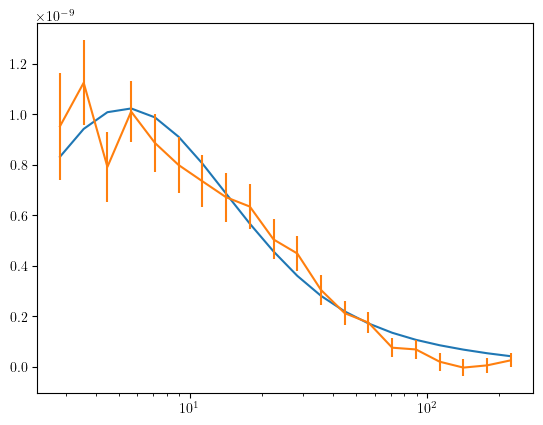

In [50]:
# xis_test.gty_out_mat.shape
bj = 2
sig_all = np.sqrt(np.diag(cov_total))
pl.figure()
pl.plot(analysis_dict['angles_data_array'], xis_test.gty_out_mat[:,bj])
pl.errorbar(analysis_dict['angles_data_array'], data_vec[20*bj:20*(bj+1)], yerr=sig_all[20*bj:20*(bj+1)])
# pl.yscale('log')
pl.xscale('log')
# xis_test.gty_out_mat.shape
# bj = 3
# indsel = np.where((bin1_all == bj) & (bin2_all == bj))[0]
# sig_all = np.sqrt(np.diag(cov_total))
# pl.figure()
# pl.plot(analysis_dict['angles_data_array'], xis_test.xip_out_mat[:,bj, bj])
# pl.errorbar(analysis_dict['angles_data_array'], xi_all[indsel][0:20], yerr=sig_all[indsel][0:20])
# pl.yscale('log')
# pl.xscale('log')
# pl.show()




In [51]:
h = sim_params_dict['cosmo']['H0'] / 100.0
Ob = sim_params_dict['cosmo']['Ob0']
Om = sim_params_dict['cosmo']['Om0']
import astropy.units as u
from astropy import constants as const
import jax_cosmo.background as bkgrd
sigmat = const.sigma_T
m_e = const.m_e
c = const.c
coeff = sigmat / (m_e * (c ** 2))
oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value

from scipy.interpolate import interp1d
import jax_cosmo.background as bkgrd
z_array = profiles_test.z_array
scale_fac_a_array = 1.0 / (1.0 + z_array)
indz = 0
Ez = np.sqrt(bkgrd.growth_factor(profiles_test.cosmo_jax, scale_fac_a_array))[indz]
# M200_noh = M_array[indM]/h
h70 = h/0.7
M_array = profiles_test.M_array
Y_model_all = np.zeros(len(M_array))
Y_ss_all = np.zeros(len(M_array))
for jM in range(len(M_array)):
    Mj = M_array[jM]
    M200_noh = Mj/h
    Y_ss = 97.6 * (1/h70) * (Ez**(2/3.)) * (M200_noh/(1e15/h70))**(5/3.) * (Ob/0.043) * (0.25/Om)

    # r200_jM = BCMP_test.r200c_mat[jM, indz]
    r200_jM = profiles_test.r200c_mat[jM, indz]    
    r_array_jM = np.logspace(-2, np.log10(r200_jM), 100)
    Pe_jz_jM = profiles_test.Pe_mat_physical[:, indz, jM]
    interpPe = interp1d(np.log(profiles_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
    Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
    Y_jM = np.trapz(4 * np.pi * r_array_jM**2 * Pe_jM, r_array_jM)

    Y_model_all[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)
    Y_ss_all[jM] = Y_ss
    



/tmp/ipykernel_1937086/2487465373.py:34: RuntimeWarning: divide by zero encountered in log
  interpPe = interp1d(np.log(profiles_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
/tmp/ipykernel_1937086/2487465373.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Y_jM = np.trapz(4 * np.pi * r_array_jM**2 * Pe_jM, r_array_jM)


In [11]:
pl.figure()
pl.plot(M_array, Y_model_all, label='Best-fit', lw=2.0)
pl.plot(M_array, 1.0e-24 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$M_{200c}$', fontsize=20)
pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
pl.xlim(1e13, 1.2e15)
pl.ylim(1e-3, 2e1)
pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
# pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
pl.show()



NameError: name 'M_array' is not defined

<Figure size 640x480 with 0 Axes>

In [11]:
import configobj
import jax
import jax.numpy as jnp
import numpy as np
from astropy.io import fits
abs_path_data ='/projects/bdne/spandey3/new_godmax/GODMAX/data'
probe = 'xip_xim'
use_gty_scale_cuts = False
use_xipm_Y3_scale_cuts = False



In [12]:
fname = abs_path_data + '/DESxACT/scale_cuts_xipm_y3_gty_fid.ini'
config = configobj.ConfigObj(fname)
sc_xipm = config['shear-shear']
sc_gty = config['shear-tsz']

df_cs = fits.open(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])
ang_vals = df_cs['xip'].data['ANG'][0:20]


def process_indices(num, bin_vals, angle_ranges, offset, probe, angle_type, do_scalecuts):
    indices, indrm = [], []
    for js in range(num):
        binv, thetav = divmod(js, 20)
        bin1, bin2 = (bin_vals[binv] - 1, bin_vals[binv] - 1) if angle_type != 'gty' else (None, None)
        if do_scalecuts:
            sc_min, sc_max = map(float, angle_ranges[binv].split())
        else:
            sc_min, sc_max = 1e-3, 999.0
        if sc_min < ang_vals[thetav] < sc_max:
            indices.append([int(thetav), int(bin1), int(bin2)] if bin1 is not None else [int(thetav), int(binv)])
        elif probe in [angle_type, 'all']:
            indrm.append(int(offset + js))
    return jnp.array(indices, dtype=jnp.int32), jnp.array(indrm, dtype=jnp.int32)

# Process gty indices
sc_ranges_gty = [sc_gty[f'angle_range_gty_{biny}_0'] for biny in biny_vals]
index_gty, indrm_gty = process_indices(80, None, sc_ranges_gty, 0, probe, 'gty', use_gty_scale_cuts)
len_ind_gty = len(index_gty)
# Process xip indices
sc_ranges_xip = [sc_xipm[f'angle_range_xip_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xip = 80 if probe in ['gty', 'all'] else 0
index_xip, indrm_xip = process_indices(200, bin1_vals, sc_ranges_xip, offset_xip, probe, 'xip_xim', use_xipm_Y3_scale_cuts)
len_ind_xip = len(index_xip)
# Process xim indices
sc_ranges_xim = [sc_xipm[f'angle_range_xim_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xim = 280 if probe in ['gty', 'all'] else 200
index_xim, indrm_xim = process_indices(200, bin1_vals, sc_ranges_xim, offset_xim, probe, 'xip_xim', use_xipm_Y3_scale_cuts)
len_ind_xim = len(index_xim)
# Combine results
indrm = jnp.concatenate([indrm_gty, indrm_xip, indrm_xim], dtype=jnp.int32)



In [13]:

indrm
# indrm_xip
# ang_vals

Array([], shape=(0,), dtype=int32)

In [14]:
# sc_xipm
len(indrm)


0